## 7 Questions for user
# 1.Ask basic question
- Q1. How big is  data
- q2. how does the data look like.
- q3. what is the data colms.
- q4. are there missing values
- q5. how does look mathematically
- q6. are there duplicates
- q7. how is the correlation
# 2.Eda univeriate 
# 3.EDA multivariate
# 4.pandas profiler to automate eda


The Titanic dataset is a classic in data science, used to predict which passengers survived the shipwreck. Each column (or "feature") gives us a specific piece of information about the individuals on board. Think of it like a digital passenger manifest that helps us play detective to see who had the best odds of making it to safety.

Here is a breakdown of what those column names actually represent:

* **PassengerId:** A unique ID number assigned to each passenger.
* **Survived:** Whether the passenger survived (0 = No, 1 = Yes).
* **Pclass:** Ticket class (1 = 1st/Upper, 2 = 2nd/Middle, 3 = 3rd/Lower)—a proxy for socio-economic status.
* **Name, Sex, & Age:** The passenger's name, gender, and age in years.
* **SibSp:** Number of **Sib**lings or **Sp**ouses aboard.
* **Parch:** Number of **Par**ents or **Ch**ildren aboard.
* **Ticket:** The ticket serial number.
* **Fare:** The amount of money the passenger paid for the trip.
* **Cabin:** The cabin number (if known).
* **Embarked:** The port where the passenger boarded (C = Cherbourg, Q = Queenstown, S = Southampton).

---

### Learning Plan

To help you master this dataset for data analysis or machine learning, I've put together a step-by-step plan:
**Proposed Plan:**

1. **Data Types:** Learning the difference between numbers (Age) and categories (Sex).
2. **Visualizing Survival:** Seeing how Class and Gender influenced who survived.
3. **Feature Engineering:** Creating new info, like "Family Size," from existing columns.

**Step 1: Understanding Data Types**
Before we crunch numbers, we need to know what *kind* of data we have. In the Titanic set, we have **Numerical** data (like `Fare`, which you can do math on) and **Categorical** data (like `Embarked`, which represents a group or place).

Think of it like a grocery receipt: The "Price" is numerical, but the "Department" (Produce, Dairy) is categorical.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df= pd.read_csv("tested.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


### Step 1: Loading the Data
First, we load the Titanic dataset from a CSV file using pandas. This creates a DataFrame that we'll use for all our analysis.

In [3]:
# how big is the dataset?
df.shape

(418, 12)

In [30]:
# how does data lool like?
# print(df.head())
# print(df.sample(n=5))
df.sample(n=5) # give better look of  data than head() because it gives random sample of data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
56,948,0,3,"Cor, Mr. Bartol",male,35.00,0,0,349230,7.8958,NaN,S
108,1000,0,3,"Willer, Mr. Aaron (Abi Weller"")""",male,NaN,0,0,3410,8.7125,NaN,S
201,1093,0,3,"Danbom, Master. Gilbert Sigvard Emanuel",male,0.33,0,2,347080,14.4000,NaN,S
371,1263,1,1,"Wilson, Miss. Helen Alice",female,31.00,0,0,16966,134.5000,E39 E41,C
166,1058,0,1,"Brandeis, Mr. Emil",male,48.00,0,0,PC 17591,50.4958,B10,C


In [5]:
# df.columns # to get the columns name and data types for future opimization
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None


In [6]:
df.isna().sum()# to get the count of null values in each column

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

### Step 4: Checking for Missing Values
Missing values (NaN) can affect our analysis. Let's count how many missing values we have in each column.

In [7]:
# df.describe(numeric_only=True) # to get the statistical summary of the data # but it will be wrong because the classification column is also in numeric form and it will be included in the summary

survived=df.groupby("Survived").count() # grupby is used to group the data by the values in the "Survived" column and count() is used to count the number of occurrences of each value in the "Survived" column

# df.groupby("Survived")['Age'].count()  #dont use this because there are na values in age and, our count will be wrong
survived 

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Survived,,,,,,,,,,,
0,266,266,266,266,205,266,266,266,265,47,266
1,152,152,152,152,127,152,152,152,152,44,152


In [8]:
social_class=df.groupby("Pclass").count()# to group the data by the values in the "Pclass" column and count() is used to count the number of occurrences of each value in the "Pclass" column

social_class

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Pclass,,,,,,,,,,,
1,107,107,107,107,98,107,107,107,107,80,107
2,93,93,93,93,88,93,93,93,93,7,93
3,218,218,218,218,146,218,218,218,217,4,218


### Step 5: Analyzing by Passenger Class
Now let's group passengers by their ticket class (1st, 2nd, or 3rd class) to see the distribution across socio-economic status.

In [9]:
doesntsurvived=df[df['Survived']==1]
doesntsurvived.count()

PassengerId    152
Survived       152
Pclass         152
Name           152
Sex            152
Age            127
SibSp          152
Parch          152
Ticket         152
Fare           152
Cabin           44
Embarked       152
dtype: int64

### Step 6: Comparing Survivors vs. Non-Survivors
We'll filter the data into two groups: those who survived (Survived = 1) and those who didn't (Survived = 0). This allows us to compare characteristics between the two groups.

In [10]:
df.groupby("Pclass")[['Age','Fare','Parch','SibSp']].mean(numeric_only=True)


,Age,Fare,Parch,SibSp
Pclass,,,,
1,40.918367,94.280297,0.383178,0.476636
2,28.777500,22.202104,0.344086,0.376344
3,24.027945,12.459678,0.417431,0.463303


### Step 7: Average Passenger Features by Class
Let's calculate the mean (average) values of Age, Fare, Family connections (Parch, SibSp) grouped by passenger class to see how they vary across socio-economic status.

In [31]:
# survived=df[df['Survived']==0]
# didntsurvived=df[df['Survived']==1]
# print(survived['Name'].count())
# print(didntsurvived['Name'].count())
df['Survived'].value_counts()


Survived
0    266
1    152
Name: count, dtype: int64

### Step 8: Counting Deaths and Survivors
Let's get the exact count of how many people survived and how many didn't. This gives us a clear picture of survival rates.

In [12]:
# q6 check for duplicates
df.duplicated().sum()

np.int64(0)

In [13]:
# check for correlation between the features
df.corr(numeric_only=True)*100

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,100.000000,-2.324514,-2.675073,-3.410191,0.381832,4.308045,0.821149
Survived,-2.324514,100.000000,-10.861452,-0.001268,9.994337,15.912011,19.151374
Pclass,-2.675073,-10.861452,100.000000,-49.214276,0.108672,1.872063,-57.714731
Age,-3.410191,-0.001268,-49.214276,100.000000,-9.158679,-6.124863,33.793158
SibSp,0.381832,9.994337,0.108672,-9.158679,100.000000,30.689462,17.153913
Parch,4.308045,15.912011,1.872063,-6.124863,30.689462,100.000000,23.004555
Fare,0.821149,19.151374,-57.714731,33.793158,17.153913,23.004555,100.000000




Reading a correlation matrix (`df.corr()`) is like looking at a "Relationship Map" between your columns. Just like `.mean()`, you'll want to use `numeric_only=True` to avoid errors!

The output is a grid where every number is between **-1 and 1**:

1. **The Number 1.0 (The Diagonal):** You'll see a line of 1.0s going from top-left to bottom-right. This is just a column comparing itself to itself (e.g., Age is 100% correlated with Age).
2. **Positive Correlation (0 to 1):** If the number is positive, the two columns move together.
* *Titanic Example:* **Fare and Survived** (). As Fare goes up, survival chances tend to go up.


3. **Negative Correlation (-1 to 0):** If the number is negative, they move in opposite directions.
* *Titanic Example:* **Pclass and Fare** (). Remember, 1st class is a *smaller* number than 3rd class. So, as Fare goes up, the Pclass number goes *down*.


4. **Near Zero:** If the number is close to 0, there is no clear linear relationship (e.g., `PassengerId` and `Survived` is ). Your ID number didn't help you survive!

### Why this helps our Detective Work (Target vs. Features)

Correlation helps us pick our **Features**. If we want to predict our **Target** (`Survived`), we look for the features with the strongest correlation (highest positive or lowest negative numbers).



## Univariate Analysis

**Definition**: Univariate analysis examines **one variable at a time** to understand its characteristics, distribution, and patterns.

**Why is it important?**
- Get summary statistics (mean, median, std dev, min, max)
- Identify missing values and outliers
- Understand the shape of distribution
- Find patterns and anomalies in individual variables


In [ ]:
%pip install seaborn

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
# Step 1: Get Summary Statistics for the data
print("=" * 60)
print("SUMMARY STATISTICS - NUMERICAL VARIABLES")
print("=" * 60)
print(df.describe())
print("\n")

print("=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

SUMMARY STATISTICS - NUMERICAL VARIABLES
       PassengerId    Survived      Pclass         Age       SibSp  \
count   418.000000  418.000000  418.000000  332.000000  418.000000   
mean   1100.500000    0.363636    2.265550   30.272590    0.447368   
std     120.810458    0.481622    0.841838   14.181209    0.896760   
min     892.000000    0.000000    1.000000    0.170000    0.000000   
25%     996.250000    0.000000    1.000000   21.000000    0.000000   
50%    1100.500000    0.000000    3.000000   27.000000    0.000000   
75%    1204.750000    1.000000    3.000000   39.000000    1.000000   
max    1309.000000    1.000000    3.000000   76.000000    8.000000   

            Parch        Fare  
count  418.000000  417.000000  
mean     0.392344   35.627188  
std      0.981429   55.907576  
min      0.000000    0.000000  
25%      0.000000    7.895800  
50%      0.000000   14.454200  
75%      0.000000   31.500000  
max      9.000000  512.329200  


DATA TYPES
PassengerId      int64
Surv

### Part 1: Categorical Variables Analysis
**Categorical variables**: These are discrete values like 'Yes/No', categories, or classes
**Best visualizations**: Countplots (frequency) and Pie charts (proportions)


1. SURVIVED - Categorical Variable
----------------------------------------
Count of each category:
Survived
0    266
1    152
Name: count, dtype: int64

Proportions (%):
Survived
0    63.636364
1    36.363636
Name: proportion, dtype: float64


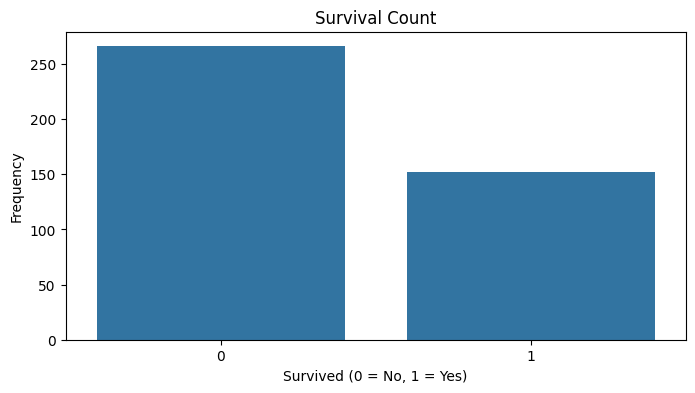

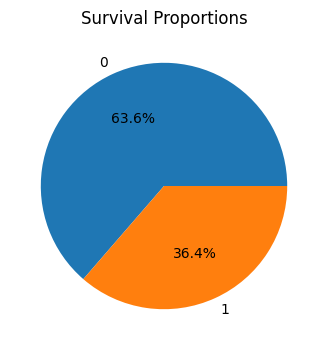

In [29]:
# CATEGORICAL 1: Survival Status (0=No, 1=Yes)
print("\n1. SURVIVED - Categorical Variable")
print("-" * 40)
print("Count of each category:")
print(df['Survived'].value_counts())
print("\nProportions (%):")
print(df['Survived'].value_counts(normalize=True) * 100)

# Visualization 1: Countplot
plt.figure(figsize=(8, 4))
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Frequency')
plt.show()

# Visualization 2: Pie Chart
plt.figure(figsize=(6, 4))
df['Survived'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Survival Proportions')
plt.ylabel('')
plt.show()


2. PASSENGERS CLASS - Categorical Variable
----------------------------------------
Count of each class:
Pclass
1    107
2     93
3    218
Name: count, dtype: int64


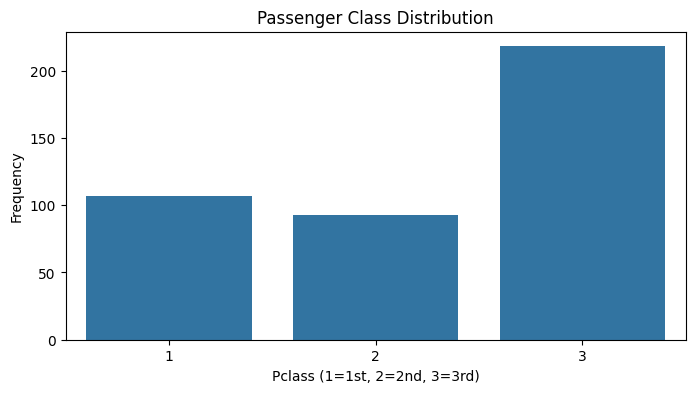

In [33]:
# CATEGORICAL 2: Passenger Class (1st, 2nd, 3rd)
print("\n2. PASSENGERS CLASS - Categorical Variable")
print("-" * 40)
print("Count of each class:")
print(df['Pclass'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.xlabel('Pclass (1=1st, 2=2nd, 3=3rd)')
plt.ylabel('Frequency')
plt.show()


3. SEX - Categorical Variable
----------------------------------------
Sex
male      266
female    152
Name: count, dtype: int64

4. EMBARKED - Categorical Variable (Port)
----------------------------------------
Embarked
S    270
C    102
Q     46
Name: count, dtype: int64


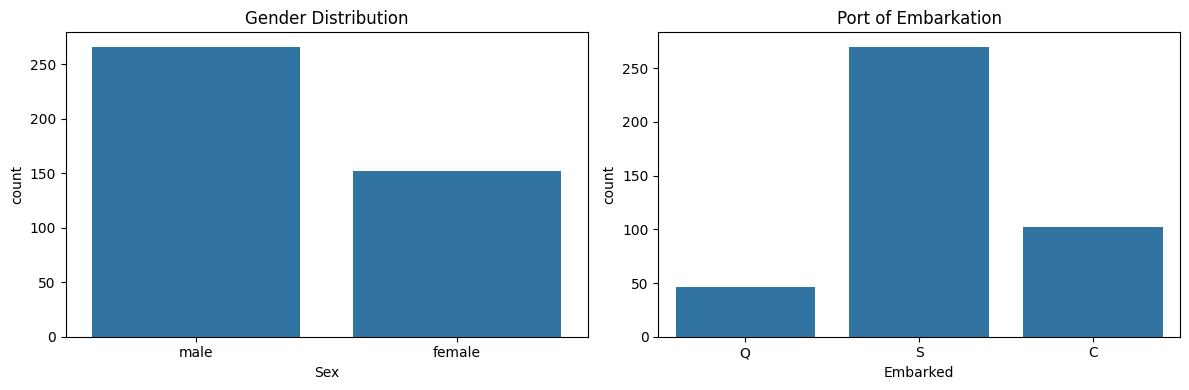

In [34]:
# CATEGORICAL 3: Sex and Embarked Port
print("\n3. SEX - Categorical Variable")
print("-" * 40)
print(df['Sex'].value_counts())

print("\n4. EMBARKED - Categorical Variable (Port)")
print("-" * 40)
print(df['Embarked'].value_counts())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='Sex', data=df)
plt.title('Gender Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x='Embarked', data=df)
plt.title('Port of Embarkation')
plt.tight_layout()
plt.show()

### Part 2: Numerical Variables Analysis
**Numerical variables**: These are continuous values like age, price, measurements
**Best visualizations**: Histograms, Distribution plots, and Box plots


5. AGE - Numerical Variable
----------------------------------------
Summary Statistics:
count    332.000000
mean      30.272590
std       14.181209
min        0.170000
25%       21.000000
50%       27.000000
75%       39.000000
max       76.000000
Name: Age, dtype: float64

Missing values: 86


C:\Users\rosha\AppData\Local\Temp\ipykernel_17072\2894881695.py:21: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'], bins=20, color='orange')


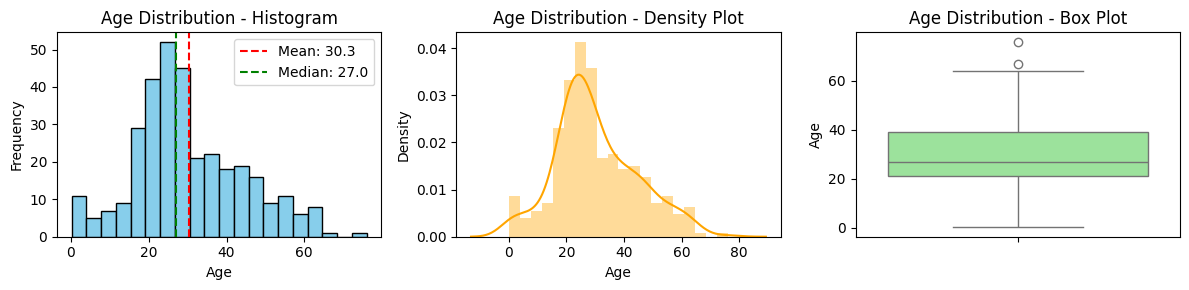


Box Plot Explanation:
  Q1 (25th percentile): 21.0
  Q2 (Median/50th): 27.0
  Q3 (75th percentile): 39.0
  IQR (Q3-Q1): 18.0


In [35]:
# NUMERICAL VARIABLE: Age
print("\n5. AGE - Numerical Variable")
print("-" * 40)
print("Summary Statistics:")
print(df['Age'].describe())
print(f"\nMissing values: {df['Age'].isna().sum()}")

# Visualization 1: Histogram (basic distribution)
plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.hist(df['Age'], bins=20, edgecolor='black', color='skyblue')
plt.title('Age Distribution - Histogram')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
plt.axvline(df['Age'].median(), color='green', linestyle='--', label=f'Median: {df["Age"].median():.1f}')
plt.legend()

# Visualization 2: Distribution Plot (histogram + density curve)
plt.subplot(1, 3, 2)
sns.distplot(df['Age'], bins=20, color='orange')
plt.title('Age Distribution - Density Plot')

# Visualization 3: Box Plot (quartiles and outliers)
plt.subplot(1, 3, 3)
sns.boxplot(data=df, y='Age', color='lightgreen')
plt.title('Age Distribution - Box Plot')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

# Explanation of Box Plot
print("\nBox Plot Explanation:")
print(f"  Q1 (25th percentile): {df['Age'].quantile(0.25):.1f}")
print(f"  Q2 (Median/50th): {df['Age'].quantile(0.50):.1f}")
print(f"  Q3 (75th percentile): {df['Age'].quantile(0.75):.1f}")
print(f"  IQR (Q3-Q1): {df['Age'].quantile(0.75) - df['Age'].quantile(0.25):.1f}")

### Key Takeaways from Univariate Analysis:
1. **Survive**: Dataset is imbalanced (more non-survivors than survivors)
2. **Pclass**: Most passengers were in 3rd class
3. **Age**: Distribution is right-skewed, average age ~30 years
4. **Sex**: More male passengers than female
5. **Embarked**: Most embarked from port C (Cherbourg)